#### Imports and env loading

Load environment variables, imports, and verify LangSmith tracing configuration.

In [154]:
from dotenv import load_dotenv

load_dotenv(dotenv_path=".env", override=True)

import os
import re
import uuid
from typing import Annotated, Any, Literal, Optional

import gradio as gr
from IPython.display import Image, Markdown, display
from langchain.tools import tool
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langgraph.types import Command, interrupt
from langsmith.utils import get_env_var, get_tracer_project
from pydantic import BaseModel, Field

get_env_var.cache_clear()
get_tracer_project.cache_clear()

if not os.getenv("LANGSMITH_API_KEY"):
    raise RuntimeError("LANGSMITH_API_KEY missing after load_dotenv")
if os.getenv("LANGSMITH_TRACING", "").lower() != "true":
    raise RuntimeError("Set LANGSMITH_TRACING=true in .env")

print(
    f"LangSmith: project={os.getenv('LANGSMITH_PROJECT')!r} "
    f"endpoint={os.getenv('LANGSMITH_ENDPOINT')!r}"
)

LangSmith: project='AgentBridge' endpoint='https://eu.api.smith.langchain.com'


#### Define constants and system prompts

Each prompt is scoped to one workflow node. Framework candidates are not hardcoded.

In [155]:
agent_name = "Framework Chooser"
MAX_SEARCH_CALLS = 2
MAX_SOURCES = 8

input_check_system_prompt = """
You are an input-check node for an AI agent/RAG framework chooser.

Your job is to decide whether there is enough context to start a framework recommendation.

Do NOT recommend a framework.
Do NOT search web.

Critical context:
1. Agent goal or framework-selection question
2. Client/company context
3. Tech stack or platform
4. Data sources or integrations
5. Team/ownership constraints

If at least 4 of these 5 are present, mark input as ready.

Important but optional context:
- security/compliance/privacy details
- latency target
- budget
- observability/audit logging
- deployment constraints
- exact approval workflow

Do NOT block the analysis only because optional context is missing.
Instead, let later nodes treat missing optional context as assumptions, risks, or follow-up questions.

If input is not ready:
- ask max 3 short follow-up questions
- ask only for missing critical context

If input is ready:
- continue the workflow
"""

client_context_system_prompt = """
Extract the client requirements for an AI agent/RAG framework recommendation.
Do not recommend frameworks. Do not search web. Keep unknown fields as empty lists or null.
Return concise structured data only.
"""

research_fact_system_prompt = """
Convert search_web tool outputs into concise source-backed framework research.
Use only the provided tool outputs. Do not invent frameworks, facts, or URLs.
Extract source titles, URLs, summaries, source type, reliability, and framework facts.
If a framework name is unclear from a source, use "unknown from source".
Keep facts short and cite source URLs exactly as provided.
"""

research_tool_system_prompt = """
You are the research node for an AI agent/RAG framework chooser.
Decide how to search for current framework information, then call search_web.
Use at most 2 search_web calls.
Search for real frameworks, SDKs, and orchestration platforms only.
Prefer official docs, GitHub repos, release notes, and vendor documentation.
Do not recommend a winner here.
"""

framework_analyst_system_prompt = """
Create concise framework profiles from source-backed research facts.
Use only the provided facts and sources. Do not recommend a winner.
If a field is not supported by the sources, write "unknown from sources".
"""

comparison_system_prompt = """
Compare discovered frameworks against the extracted client context.
Choose the highest client-fit option based on evidence, not popularity.
Do not introduce new framework candidates. If evidence is weak, lower confidence and explain what is missing.
"""

recommendation_writer_system_prompt = """
Write the final framework recommendation using only:
- extracted client context
- research sources
- framework profiles
- comparison result

Do not search web. Do not introduce new frameworks. Do not invent sources.
The final answer must be Markdown with exactly these sections:

## Recommendation
Primary framework, 1-2 alternatives, and why they fit this client.

## Framework comparison
| Framework | Score | Best fit | Main trade-off |
|---|---:|---|---|

## Sources
- **[Title](URL)** - short explanation of what this source supported.

## Risks
3-5 concrete risks.
Format each as:
- **Risk:** ...
  - **Impact:** Low/Medium/High
  - **Mitigation:** ...

## PoC metrics
Metrics for a 2-4 week PoC. Include Metric, Target, and How to measure.
Make risks and PoC metrics specific to the client context.
"""

#### Define LLM

Use the same small model for the notebook, with a bounded timeout.

In [156]:
llm = ChatOpenAI(model="gpt-5-nano", timeout=120, max_retries=1)

#### Define state schemas

State keeps each workflow artifact inspectable between nodes.

In [157]:
class SourceItem(BaseModel):
    title: str = "Untitled"
    url: str = ""
    summary: str = ""
    source_type: Literal[
        "official_docs",
        "github",
        "release_notes",
        "vendor_docs",
        "technical_blog",
        "other",
    ] = "other"
    reliability: Literal["high", "medium", "low"] = "medium"


class RawFrameworkFact(BaseModel):
    framework: str = "unknown from source"
    fact: str
    source_url: str
    reliability: Literal["high", "medium", "low"] = "medium"


class FrameworkProfile(BaseModel):
    name: str
    main_purpose: str = "unknown from sources"
    strengths: list[str] = Field(default_factory=list)
    weaknesses: list[str] = Field(default_factory=list)
    orchestration_style: str = "unknown from sources"
    rag_support: str = "unknown from sources"
    tool_support: str = "unknown from sources"
    workflow_control: str = "unknown from sources"
    state_management: str = "unknown from sources"
    human_in_the_loop: str = "unknown from sources"
    observability: str = "unknown from sources"
    production_readiness: str = "unknown from sources"
    enterprise_suitability: str = "unknown from sources"
    source_urls: list[str] = Field(default_factory=list)


class ComparisonItem(BaseModel):
    framework: str
    score: int = Field(ge=0, le=25)
    max_score: int = 25
    why_it_fits: str
    main_tradeoff: str
    best_for_this_client_if: str


class FrameworkComparison(BaseModel):
    comparison: list[ComparisonItem] = Field(default_factory=list)
    winner: Optional[str] = None
    runner_up: Optional[str] = None
    decision_reason: str = ""
    confidence: Literal["high", "medium", "low"] = "medium"


class AgentBridgeState(BaseModel):
    messages: Annotated[list, add_messages] = Field(default_factory=list)

    user_question: Optional[str] = None
    platform_description: Optional[str] = None
    uploaded_document_ids: list[str] = Field(default_factory=list)

    input_check_passed: bool = False
    missing_items: list[str] = Field(default_factory=list)
    clarification_questions: list[str] = Field(default_factory=list)

    client_context: dict[str, Any] | None = None
    research_queries: list[str] = Field(default_factory=list)
    research_sources: list[dict[str, Any]] = Field(default_factory=list)
    raw_framework_facts: list[dict[str, Any]] = Field(default_factory=list)
    framework_profiles: list[dict[str, Any]] = Field(default_factory=list)
    framework_comparison: dict[str, Any] | None = None
    final_recommendation: Optional[str] = None
    final_answer: Optional[str] = None

#### Define tools

The research node calls search directly and limits the workflow to two search calls.

In [158]:
serper = GoogleSerperAPIWrapper(k=5)


def classify_source(url: str) -> tuple[str, str]:
    url_lower = (url or "").lower()
    if "github.com" in url_lower:
        return "github", "high"
    if "docs." in url_lower or "/docs" in url_lower or "documentation" in url_lower:
        return "official_docs", "high"
    if "release" in url_lower or "changelog" in url_lower:
        return "release_notes", "high"
    if any(host in url_lower for host in ["medium.com", "substack.com", "dev.to"]):
        return "technical_blog", "medium"
    return "other", "medium"


def _search_sources(query: str) -> list[dict[str, Any]]:
    results = serper.results(query)
    sources = []

    for item in results.get("organic", [])[: serper.k]:
        url = item.get("link", "")
        source_type, reliability = classify_source(url)
        sources.append(
            SourceItem(
                title=item.get("title") or "Untitled",
                url=url,
                summary=(item.get("snippet") or "").replace("\n", " "),
                source_type=source_type,
                reliability=reliability,
            ).model_dump()
        )

    return sources


@tool
def search_web(query: str) -> str:
    """Search the web for current information. Returns titles, URLs, and snippets to cite as sources."""
    sources = _search_sources(query)
    if not sources:
        return f"Query: {query}\nNo search results found."

    lines = [f"Query: {query}", ""]
    for i, source in enumerate(sources, 1):
        lines.extend(
            [
                f"[{i}] {source['title']}",
                f"URL: {source['url']}",
                f"Snippet: {source['summary']}",
                f"Reliability: {source['reliability']}",
                "",
            ]
        )
    return "\n".join(lines)



#### Helper functions

Small utilities for thread config, interrupts, state inspection, and source display.

In [159]:
def get_user_question(state: AgentBridgeState) -> str | None:
    if state.user_question:
        return state.user_question

    for message in reversed(state.messages):
        role = getattr(message, "type", None) or getattr(message, "role", None)
        if role in {"human", "user"}:
            return message.content

    return None


def make_graph_config(thread_id: str | None = None) -> dict:
    return {
        "configurable": {"thread_id": thread_id or f"agentbridge-{uuid.uuid4().hex}"},
        "recursion_limit": 12,
    }


def get_interrupt_payload(result: dict) -> dict | None:
    interrupts = result.get("__interrupt__") or []
    if not interrupts:
        return None
    return interrupts[0].value


def format_interrupt_payload(payload: dict) -> str:
    questions = payload.get("questions") or payload.get("clarification_questions") or []
    question_block = "\n".join(f"- {question}" for question in questions)
    return f"{payload.get('message', 'I need more information.')}\n\n{question_block}".strip()


def format_graph_result(result: dict) -> str:
    if payload := get_interrupt_payload(result):
        return format_interrupt_payload(payload)
    if result.get("final_recommendation"):
        return result["final_recommendation"]
    if result.get("final_answer"):
        return result["final_answer"]
    messages = result.get("messages") or []
    if messages:
        return messages[-1].content
    return "The graph finished without producing a message."


def resume_value_to_text(value: Any) -> str:
    if isinstance(value, str):
        return value
    if isinstance(value, dict):
        return "\n".join(f"{key}: {val}" for key, val in value.items())
    return str(value)


def as_compact_json(data: Any) -> str:
    import json

    return json.dumps(data, ensure_ascii=False, indent=2)


def dedupe_sources(sources: list[dict[str, Any]]) -> list[dict[str, Any]]:
    seen = set()
    deduped = []
    for source in sources:
        url = source.get("url")
        if not url or url in seen:
            continue
        seen.add(url)
        deduped.append(source)
    return deduped[:MAX_SOURCES]


def pretty_print_state_keys(state: dict) -> None:
    for key in [
        "input_check_passed",
        "missing_items",
        "clarification_questions",
        "client_context",
        "research_queries",
        "research_sources",
        "framework_profiles",
        "framework_comparison",
    ]:
        print(f"{key}: {state.get(key)}")


def print_sources(state: dict) -> None:
    for source in state.get("research_sources", []):
        print(f"- {source.get('title')} -> {source.get('url')}")

#### Input check node

Checks if there is enough information. If not, it interrupts and asks short follow-up questions.

In [160]:
class InputCheckResult(BaseModel):
    can_continue: bool = Field(description="True when the workflow can continue to context extraction.")
    user_question: Optional[str] = Field(default=None, description="Cleaned framework-selection question or goal.")
    platform_description: Optional[str] = Field(default=None, description="Client/platform context found in the conversation.")
    missing_items: list[str] = Field(default_factory=list)
    clarification_questions: list[str] = Field(default_factory=list)


input_check_model = llm.with_structured_output(InputCheckResult)


def input_check_node(state: AgentBridgeState) -> dict:
    user_input = get_user_question(state) or ""
    platform_context = state.platform_description or ""

    while True:
        result = input_check_model.invoke(
            [
                SystemMessage(content=input_check_system_prompt),
                HumanMessage(
                    content=(
                        f"User input:\n{user_input}\n\n"
                        f"Known platform context:\n{platform_context or '<none>'}\n\n"
                        f"Uploaded document ids: {state.uploaded_document_ids}"
                    )
                ),
            ]
        )

        if result.can_continue:
            return {
                "user_question": result.user_question or user_input,
                "platform_description": result.platform_description or platform_context,
                "input_check_passed": True,
                "missing_items": [],
                "clarification_questions": [],
            }

        questions = result.clarification_questions[:5] or [
            "Can you describe the client, tech stack, data sources, constraints, and target agent workflow?"
        ]
        human_answer = interrupt(
            {
                "type": "input_check_missing_information",
                "message": "I need more information before starting the analysis.",
                "missing_items": result.missing_items,
                "questions": questions,
            }
        )

        user_input = f"{user_input}\n\nUser clarification:\n{resume_value_to_text(human_answer)}"


def route_after_input_check(state: AgentBridgeState) -> str:
    return "ready" if state.input_check_passed else "needs_more_context"

#### Client context extractor node

Extracts structured client requirements. It does not search or recommend.

In [161]:
class ClientContextResult(BaseModel):
    company_context: Optional[str] = None
    industry: Optional[str] = None
    company_size: Optional[str] = None
    tech_stack: list[str] = Field(default_factory=list)
    hosting_or_deployment: list[str] = Field(default_factory=list)
    data_sources: list[str] = Field(default_factory=list)
    integrations: list[str] = Field(default_factory=list)
    security_constraints: list[str] = Field(default_factory=list)
    compliance_constraints: list[str] = Field(default_factory=list)
    team_constraints: list[str] = Field(default_factory=list)
    workflow_requirements: list[str] = Field(default_factory=list)
    latency_or_budget: list[str] = Field(default_factory=list)
    framework_selection_needs: list[str] = Field(default_factory=list)


client_context_model = llm.with_structured_output(ClientContextResult)


def client_context_extractor_node(state: AgentBridgeState) -> dict:
    result = client_context_model.invoke(
        [
            SystemMessage(content=client_context_system_prompt),
            HumanMessage(
                content=(
                    f"Framework question:\n{state.user_question or get_user_question(state) or ''}\n\n"
                    f"Client/platform context:\n{state.platform_description or '<none>'}\n\n"
                    f"Uploaded document ids: {state.uploaded_document_ids}"
                )
            ),
        ]
    )
    return {"client_context": result.model_dump()}

#### Framework research node

Builds neutral search queries from client context and performs at most two search calls.

In [162]:
class FrameworkResearchResult(BaseModel):
    research_queries: list[str] = Field(default_factory=list)
    sources: list[SourceItem] = Field(default_factory=list)
    raw_framework_facts: list[RawFrameworkFact] = Field(default_factory=list)


research_tool_model = llm.bind_tools([search_web])
research_result_model = llm.with_structured_output(FrameworkResearchResult)


def get_search_tool_outputs(messages: list) -> list[dict[str, str]]:
    tool_queries_by_id = {}
    outputs = []

    for message in messages:
        for tool_call in getattr(message, "tool_calls", []) or []:
            if tool_call.get("name") == "search_web":
                tool_queries_by_id[tool_call.get("id")] = (tool_call.get("args") or {}).get("query", "")

        if getattr(message, "type", None) == "tool" and getattr(message, "name", None) == "search_web":
            outputs.append(
                {
                    "query": tool_queries_by_id.get(getattr(message, "tool_call_id", None), ""),
                    "output": message.content,
                }
            )

    return outputs[-MAX_SEARCH_CALLS:]


def framework_research_node(state: AgentBridgeState) -> dict:
    tool_outputs = get_search_tool_outputs(state.messages)
    if not tool_outputs:
        tool_request = research_tool_model.invoke(
            [
                SystemMessage(content=research_tool_system_prompt),
                HumanMessage(
                    content=(
                        f"Client context:\n{as_compact_json(state.client_context or {})}\n\n"
                        "Call search_web with the queries you need. Use at most 2 calls."
                    )
                ),
            ]
        )
        tool_request = AIMessage(content=tool_request.content, tool_calls=(tool_request.tool_calls or [])[:MAX_SEARCH_CALLS])
        return {"messages": [tool_request]}

    research_result = research_result_model.invoke(
        [
            SystemMessage(content=research_fact_system_prompt),
            HumanMessage(
                content=(
                    f"Client context:\n{as_compact_json(state.client_context or {})}\n\n"
                    f"search_web tool outputs:\n{as_compact_json(tool_outputs)}"
                )
            ),
        ]
    )

    return {
        "research_queries": research_result.research_queries[:MAX_SEARCH_CALLS],
        "research_sources": dedupe_sources([source.model_dump() for source in research_result.sources]),
        "raw_framework_facts": [fact.model_dump() for fact in research_result.raw_framework_facts],
    }


def route_after_framework_research(state: AgentBridgeState) -> str:
    last_message = state.messages[-1] if state.messages else None
    if getattr(last_message, "tool_calls", None):
        return "research_tools"
    return "framework_analyst"


#### Framework analyst node

Turns source-backed facts into framework profiles. It does not choose a winner.

In [163]:
class FrameworkProfilesResult(BaseModel):
    framework_profiles: list[FrameworkProfile] = Field(default_factory=list)


framework_analyst_model = llm.with_structured_output(FrameworkProfilesResult)


def framework_analyst_node(state: AgentBridgeState) -> dict:
    result = framework_analyst_model.invoke(
        [
            SystemMessage(content=framework_analyst_system_prompt),
            HumanMessage(
                content=(
                    f"Client context:\n{as_compact_json(state.client_context or {})}\n\n"
                    f"Research sources:\n{as_compact_json(state.research_sources)}\n\n"
                    f"Raw framework facts:\n{as_compact_json(state.raw_framework_facts)}"
                )
            ),
        ]
    )
    return {"framework_profiles": [profile.model_dump() for profile in result.framework_profiles]}

#### Comparison node

Scores the discovered frameworks against the client context.

In [164]:
comparison_model = llm.with_structured_output(FrameworkComparison)


def comparison_node(state: AgentBridgeState) -> dict:
    result = comparison_model.invoke(
        [
            SystemMessage(content=comparison_system_prompt),
            HumanMessage(
                content=(
                    f"Client context:\n{as_compact_json(state.client_context or {})}\n\n"
                    f"Framework profiles:\n{as_compact_json(state.framework_profiles)}\n\n"
                    f"Sources:\n{as_compact_json(state.research_sources)}"
                )
            ),
        ]
    )
    return {"framework_comparison": result.model_dump()}

#### Recommendation writer node

Writes the final source-backed answer. This node has no tool access.

In [165]:
def recommendation_writer_node(state: AgentBridgeState) -> dict:
    response = llm.invoke(
        [
            SystemMessage(content=recommendation_writer_system_prompt),
            HumanMessage(
                content=(
                    f"Client context:\n{as_compact_json(state.client_context or {})}\n\n"
                    f"Research sources:\n{as_compact_json(state.research_sources)}\n\n"
                    f"Framework profiles:\n{as_compact_json(state.framework_profiles)}\n\n"
                    f"Comparison result:\n{as_compact_json(state.framework_comparison or {})}"
                )
            ),
        ]
    )

    return {
        "final_recommendation": response.content,
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)],
    }

#### Build graph

The graph is a controlled workflow: input check, context extraction, research, analysis, comparison, final writing.

In [166]:
memory = MemorySaver()

graph_builder = StateGraph(AgentBridgeState)

graph_builder.add_node("input_check", input_check_node)
graph_builder.add_node("client_context_extractor", client_context_extractor_node)
graph_builder.add_node("framework_research", framework_research_node)
graph_builder.add_node("research_tools", ToolNode([search_web]))
graph_builder.add_node("framework_analyst", framework_analyst_node)
graph_builder.add_node("comparison", comparison_node)
graph_builder.add_node("recommendation_writer", recommendation_writer_node)

graph_builder.add_edge(START, "input_check")
graph_builder.add_conditional_edges(
    "input_check",
    route_after_input_check,
    {
        "ready": "client_context_extractor",
        "needs_more_context": END,
    },
)
graph_builder.add_edge("client_context_extractor", "framework_research")
graph_builder.add_conditional_edges(
    "framework_research",
    route_after_framework_research,
    {
        "research_tools": "research_tools",
        "framework_analyst": "framework_analyst",
    },
)
graph_builder.add_edge("research_tools", "framework_research")
graph_builder.add_edge("framework_analyst", "comparison")
graph_builder.add_edge("comparison", "recommendation_writer")
graph_builder.add_edge("recommendation_writer", END)

#### Compile graph with memory

The checkpointer is required for interrupt/resume in notebook and Gradio flows.

In [167]:
graph = graph_builder.compile(checkpointer=memory)

#### Display Mermaid diagram of our graph

The diagram should show all workflow nodes and the input-check route.

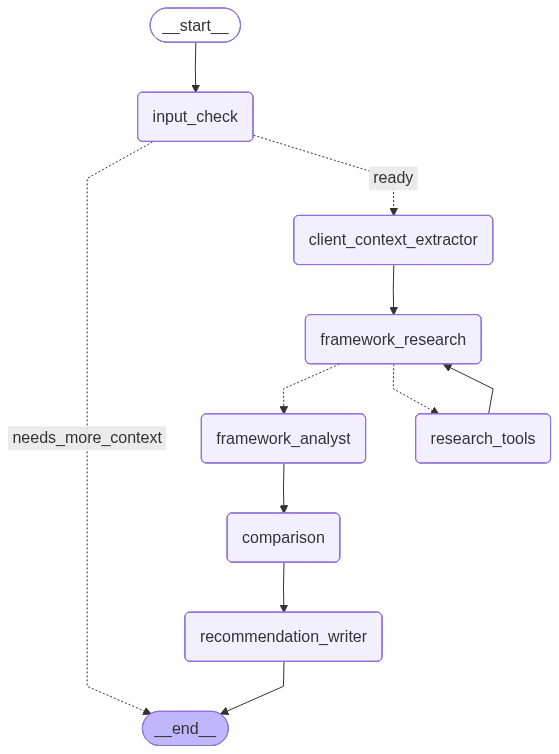

In [168]:
display(Image(graph.get_graph().draw_mermaid_png()))

#### Test examples

These cells are safe to run manually. The short input should interrupt before search.

In [169]:
# short_config = make_graph_config("agentbridge-short-input-demo")
# short_state = AgentBridgeState(
#     messages=[HumanMessage(content="What framework should I use?")],
#     user_question="What framework should I use?",
# )
# short_result = graph.invoke(short_state, config=short_config)
# Markdown(format_graph_result(short_result))

#### Resume interrupted terminal run

Use the same thread id and `Command(resume=...)` to continue after clarification.

In [170]:
# resume_answer = (
#     "We are building an internal assistant for product and support teams. "
#     "It should ingest product docs, answer questions with citations, call internal APIs, "
#     "support human approval for external actions, run on AWS, and be owned by a small Python team."
# )
# resumed_result = graph.invoke(Command(resume=resume_answer), config=short_config)
# Markdown(format_graph_result(resumed_result))

#### Enough-context workflow test

This example should run the full graph and produce a source-backed recommendation.

In [171]:
# full_question = (
#     "We are a 45-person B2B SaaS company. Our stack is Python/FastAPI, React, and AWS. "
#     "We need an agent framework for an assistant that reads product docs, queries internal APIs, "
#     "drafts workflow-specific outputs, and requires human approval before external actions. "
#     "Security matters, we have no ML team, and one senior backend engineer will own it. "
#     "What AI agent or RAG framework should we choose?"
# )
# full_result = graph.invoke(
#     AgentBridgeState(messages=[HumanMessage(content=full_question)], user_question=full_question),
#     config=make_graph_config("agentbridge-full-demo"),
# )
# Markdown(format_graph_result(full_result))

#### Gradio app

The UI starts a new graph thread per conversation and resumes the same thread after interrupts.

In [172]:
def flush_langsmith_traces() -> None:
    try:
        from langsmith import Client

        client = Client()
        if hasattr(client, "flush"):
            client.flush()
    except Exception:
        pass


def gradio_respond(user_input: str, history, thread_id: str | None, pending_interrupt):
    user_input = (user_input or "").strip()
    history = history or []
    thread_id = thread_id or f"agentbridge-gradio-{uuid.uuid4().hex}"

    if not user_input:
        return "", history, thread_id, pending_interrupt

    history.append({"role": "user", "content": user_input})
    config = make_graph_config(thread_id)

    try:
        if pending_interrupt:
            result = graph.invoke(Command(resume=user_input), config=config)
        else:
            result = graph.invoke(
                AgentBridgeState(
                    messages=[HumanMessage(content=user_input)],
                    user_question=user_input,
                    platform_description=None,
                    uploaded_document_ids=[],
                ),
                config=config,
            )

        pending_interrupt = get_interrupt_payload(result)
        assistant_message = (
            format_interrupt_payload(pending_interrupt)
            if pending_interrupt
            else format_graph_result(result)
        )
    except Exception as exc:
        pending_interrupt = None
        assistant_message = f"Error while running graph: {exc}"
    finally:
        flush_langsmith_traces()

    history.append({"role": "assistant", "content": assistant_message})
    return "", history, thread_id, pending_interrupt


def gradio_reset():
    return [], f"agentbridge-gradio-{uuid.uuid4().hex}", None


with gr.Blocks() as demo:
    gr.Markdown("## AgentBridge Framework Chooser")
    gr.Markdown(
        "Ask a framework-selection question. If required context is missing, "
        "the graph interrupts and this UI resumes the same LangGraph thread after your answer."
    )

    chatbot = gr.Chatbot()
    user_box = gr.Textbox(
        label="Message",
        placeholder="Ask a framework question, then answer the follow-up if the graph interrupts.",
    )
    with gr.Row():
        send_button = gr.Button("Send", variant="primary")
        clear_button = gr.Button("New conversation")

    thread_state = gr.State(None)
    pending_interrupt_state = gr.State(None)

    user_box.submit(
        gradio_respond,
        inputs=[user_box, chatbot, thread_state, pending_interrupt_state],
        outputs=[user_box, chatbot, thread_state, pending_interrupt_state],
    )
    send_button.click(
        gradio_respond,
        inputs=[user_box, chatbot, thread_state, pending_interrupt_state],
        outputs=[user_box, chatbot, thread_state, pending_interrupt_state],
    )
    clear_button.click(
        gradio_reset,
        outputs=[chatbot, thread_state, pending_interrupt_state],
    )


demo.launch()

* Running on local URL:  http://127.0.0.1:7868
* To create a public link, set `share=True` in `launch()`.
